# A Comparative Guide to Classification Models: LPM, Logit, KNN, and Decision Trees

This notebook provides an overview of four fundamental classification techniques: the Linear Probability Model (LPM), Logistic Regression (Logit), k-Nearest Neighbors (KNN), and Decision Trees (DT).

---

## 1. Linear Probability Model (LPM)

### Definition
The Linear Probability Model is the simplest approach to binary classification. It applies the standard Ordinary Least Squares (OLS) regression framework to a binary dependent variable (coded as 0 or 1). The model predicts the probability that an observation belongs to a particular class.

### Mathematical Formula
The model is identical to a linear regression:

$$Y_i = \beta_0 + \beta_1 X_{1i} + \beta_2 X_{2i} + ... + \beta_k X_{ki} + \varepsilon_i$$

Where:
- $Y_i$ is the binary outcome (0 or 1) for observation $i$.
- $X_{ji}$ are the predictor variables.
- $\beta_j$ are the coefficients to be estimated.
- $\varepsilon_i$ is the error term.

The predicted value, $\hat{Y}_i$, is interpreted as the **probability** that $Y_i = 1$, given the values of the predictors.

### Real-Life Use Cases
- **Initial Analysis:** Used as a baseline model in econometrics to get a quick, rough estimate of the relationship between variables.
- **Risk Assessment:** In finance, it can be used for a preliminary credit default scoring, where the result is a simple linear combination of factors like income and debt.

### Strengths
- **Simplicity:** Easy to understand, implement, and interpret.
- **Computational Speed:** Very fast to estimate.
- **Unbiased Coefficients:** The coefficients are unbiased estimates of the marginal effect of a predictor on the probability, *given the model is correctly specified*.

### Weaknesses
- **Predicted Probabilities Outside [0,1]:** The most significant flaw. The linear function can produce probabilities less than 0 or greater than 1, which are nonsensical.
- **Heteroskedasticity:** The variance of the error term is not constant, violating a key OLS assumption (Homoskedasticity (assumption of constant variance of the errors)) and making standard statistical inference (p-values, confidence intervals) invalid.
- **Linear Relationship Assumption:** It assumes a constant marginal effect of a predictor on the probability, which is often unrealistic. For example, a \$1000 increase in income might have a different effect on home-buying probability for a low-income person vs. a high-income person.

---

## 2. Logistic Regression (Logit)

### Definition
Logistic Regression is a statistical model specifically designed for binary classification. Instead of fitting a straight line, it fits an "S"-shaped logistic function to the data, ensuring that predicted probabilities are always constrained between 0 and 1.

### Mathematical Formula
Logit models the probability that $Y=1$ using the logistic function:

$$P(Y=1|X) = \frac{1}{1 + e^{-(\beta_0 + \beta_1 X_1 + ... + \beta_k X_k)}}$$

The underlying formula is often linearized by considering the **log-odds**:

$$\ln\left(\frac{P(Y=1)}{1-P(Y=1)}\right) = \beta_0 + \beta_1 X_1 + ... + \beta_k X_k$$

Here, the left-hand side is the natural logarithm of the odds ratio. The coefficients are estimated using **Maximum Likelihood Estimation (MLE)** , which finds the parameter values that make the observed data most probable.

### Real-Life Use Cases
- **Medicine:** Predicting the probability of a patient having a disease (e.g., diabetes) based on risk factors like age, BMI, and blood pressure.
- **Marketing:** Estimating the likelihood of a customer clicking on an online advertisement.
- **Finance:** A core model for credit scoring and loan default prediction.

### Strengths
- **Well-Calibrated Probabilities:** Outputs are proper probabilities bounded between 0 and 1.
- **Interpretability:** Coefficients provide insight into the direction and magnitude of an effect on the log-odds (or odds) of the outcome.
- **Feature Importance:** Allows for easy ranking of feature importance based on the absolute value of their standardized coefficients.

### Weaknesses
- **Linear Decision Boundary:** The boundary separating the classes is linear in the features (after the logit transformation). It cannot naturally capture complex, non-linear relationships without manual feature engineering (e.g., adding polynomial or interaction terms).
- **Assumption of Independence:** Observations are assumed to be independent of each other (the data points, or rows, in your dataset are not related  or influenced by one another).

---

## 3. k-Nearest Neighbors (KNN)

### Definition
KNN is a non-parametric, instance-based learning algorithm. It classifies a new data point based on the majority class among its 'k' most similar neighbors in the feature space. "Similarity" is typically defined by a distance metric.

### Mathematical Formulas
The core idea is based on distance calculation and majority voting. The choice of distance metric is crucial as it defines what "near" means.

#### Distance Metrics
The distance $d(x, x_i)$ between a new point $x$ and a training point $x_i$ can be calculated using various formulas:

- **Euclidean Distance (Most Common - $L^2$ norm):**
    The straight-line distance between two points in Euclidean space. Best for continuous numerical features where the direct geometric distance makes sense.
    $$d(x, x_i) = \sqrt{\sum_{j=1}^{p} (x_j - x_{i_j})^2}$$

- **Manhattan Distance (City Block - $L^1$ norm):**
    The sum of the absolute differences between coordinates. Often used in high-dimensional spaces or when features are not measured on the same scale; it is less sensitive to outliers than Euclidean distance.
    $$d(x, x_i) = \sum_{j=1}^{p} |x_j - x_{i_j}|$$

- **Minkowski Distance (Generalized):**
    A generalization of Euclidean and Manhattan distances. When $r=2$, it becomes Euclidean; when $r=1$, it becomes Manhattan.
    $$d(x, x_i) = \left( \sum_{j=1}^{p} |x_j - x_{i_j}|^r \right)^{1/r}$$

- **Hamming Distance:**
    Used specifically for categorical data (e.g., strings, binary variables). It counts the number of features where the values are different.
    $$d(x, x_i) = \sum_{j=1}^{p} \mathbb{1}_{x_j \neq x_{i_j}}$$
    *(Where $\mathbb{1}$ is an indicator function that equals 1 if the values are different, and 0 if they are the same.)*

#### Finding Neighbors and Voting
1.  **Find the k-nearest neighbors:** Identify the $k$ training data points with the smallest distance $d(x, x_i)$ to the new point $x$ using the chosen metric.
2.  **Majority Vote (or Weighted Vote):** The predicted class for $x$ is usually the most frequent class among its $k$ neighbors.
    $$\hat{y} = \text{mode}\{y_{i_1}, y_{i_2}, ..., y_{i_k}\}$$
    *Note: Often, votes are weighted by the inverse of the distance (closer neighbors have more say), which can improve performance.*

### Real-Life Use Cases
- **Recommendation Systems:** "Users who liked this movie also liked..." is essentially a KNN approach in user or item space (often using cosine distance, another related metric).
- **Pattern Recognition:** Handwriting recognition (e.g., identifying digits) by comparing a new image to a database of known images.
- **Data Pre-processing:** Filling in missing values by finding the most similar complete cases and imputing their values.

### Strengths
- **Simplicity:** Intuitive and easy to understand. No underlying model to train; it just memorizes the data.
- **Non-Linear Boundaries:** Can create highly complex, non-linear decision boundaries, making it flexible for many data shapes.
- **No Distributional Assumptions:** It makes no assumptions about the underlying data distribution.

### Weaknesses

- **Computationally Intensive Prediction:** Prediction requires calculating the distance to *every* training point, which can be very slow for large datasets. It's often called a "lazy learner" for this reason.

- **Sensitive to Irrelevant Features and Scale:** All features contribute equally to the distance calculation. Irrelevant or unscaled features can dominate the distance and lead to poor performance. Feature scaling (normalization/standardization) is mandatory.

- **Curse of Dimensionality:**
    This is a fundamental problem for KNN as the number of features (dimensions) increases.
    - **Sparsity:** As dimensions increase, the feature space becomes increasingly sparse. Data points become spread out, and the volume of the space grows exponentially.
    - **Distance becomes meaningless:** In high dimensions, the distance between any two points tends to converge and become roughly the same. The concept of "nearest" neighbor loses its meaning because almost all points appear equally far away (and equally close).
    - **Sample Size Requirement:** To maintain the same density of points, the required training data grows exponentially with the number of dimensions. For example, if 100 points are needed to cover a 1D line, you might need 100² = 10,000 points to cover a 2D space with the same density.
    - **Practical Consequence:** Performance degrades rapidly as dimensions increase, often making KNN perform worse than simpler models like Logit when you have many features.

### Summary
KNN is a powerful, intuitive algorithm best suited for **low-dimensional** spaces where similarity can be meaningfully measured by distance. For high-dimensional data, dimensionality reduction techniques (like PCA) are often required as a preprocessing step before applying KNN.

---

## 4. Decision Trees (DT)

### Definition
Decision Trees are a non-parametric supervised learning method used for classification and regression. They create a model that predicts the class by learning simple decision rules inferred from the data features. The model is structured as a tree, with internal nodes representing tests on features, branches representing the outcomes of the tests, and leaf nodes representing the final class prediction.

### Mathematical Formulas
The algorithm builds the tree by recursively splitting the data to maximize the "purity" of the resulting subsets (nodes). But how does it decide *where* to split (e.g., why `Age < 26` instead of `Age < 18`)?

#### The Splitting Criteria (Impurity Measures)
The tree tests every possible threshold for every feature and chooses the split that results in the purest child nodes. Common measures of impurity are:

- **Gini Impurity:** Measures how often a randomly chosen element would be incorrectly labeled if it were randomly labeled according to the distribution of classes in the node.
    $$Gini = 1 - \sum_{i=1}^{C} (p_i)^2$$
    where $p_i$ is the proportion of class $i$ in the node. A perfect node (only one class) has a Gini of 0.

- **Entropy / Information Gain:** Entropy measures the level of disorder or uncertainty. Information Gain is the reduction in entropy achieved by splitting on a feature.
    $$Entropy = -\sum_{i=1}^{C} p_i \log_2(p_i)$$
    $$Information\ Gain = Entropy(\text{parent}) - \sum_{j} \frac{N_j}{N} Entropy(\text{child}_j)$$

#### How the Tree Chooses a Split Point (e.g., Age < 26 vs. Age < 18)
The tree does not guess or use arbitrary round numbers. It performs the following steps mathematically:

1.  **Sort the Data:** For the feature `Age`, sort all unique values in the training data (e.g., 15, 18, 22, 26, 30, 35, 40...).
2.  **Test Midpoints:** It considers potential split points between these values (e.g., <16.5, <20, <24, <28, <32.5...).
3.  **Calculate Impurity:** For each potential split, it calculates the weighted impurity of the resulting two child nodes.
    - *Example A (Split at 18):* Left node (Under 18) might be pure but very small; Right node (18+) might be large and very messy (mixed classes).
    - *Example B (Split at 26):* Left node (Under 26) might be moderately pure and of decent size; Right node (26+) might also be moderately pure.
4.  **Compare and Select:** The tree calculates an impurity score for each split (e.g., Gini = 0.45 for split at 18; Gini = 0.28 for split at 26; Gini = 0.35 for split at 30). It selects the threshold that yields the **lowest impurity** (or highest information gain).
    - *Decision:* If `Age < 26` creates the most homogeneous groups (best separation of classes), the tree chooses that split.

This process is repeated recursively for every node, resulting in a tree that maximizes class separation at each step.

### Real-Life Use Cases
- **Customer Segmentation:** Segmenting customers based on demographic and behavioral data to target marketing campaigns.
- **Medical Diagnosis:** Creating a flowchart-like system to assist in diagnosing a condition based on patient symptoms and test results.
- **Fraud Detection:** Identifying potentially fraudulent transactions by learning the rules that distinguish fraud from legitimate activity.

### Strengths
- **High Interpretability:** The tree structure is easy to visualize and explain, even to non-technical audiences. You can trace the logic (e.g., "If Age < 26 and Income > $50k, then Predict Buy").
- **Handles Mixed Data:** Can easily handle both numerical and categorical data without needing dummy variables.
- **Non-Linear & Feature Interactions:** Naturally captures non-linear relationships and complex interactions between features without explicit engineering.
- **Little Data Preparation:** Does not require feature scaling.

### Weaknesses
- **Overfitting:** Prone to creating overly complex trees that memorize the training data and perform poorly on new data. This is mitigated by pruning, setting a maximum depth, or using ensemble methods (like Random Forests).
- **Instability:** Small changes in the data can lead to a completely different tree structure (high variance). Changing a few data points might change the optimal split from `Age < 26` to `Age < 30`.
- **Greedy Algorithm:** The recursive splitting algorithm makes locally optimal decisions at each node (looking for the best split *right now*), which may not lead to a globally optimal tree.

---

## Comparison Summary Table

| Feature               | LPM                             | Logistic Regression (Logit) | k-Nearest Neighbors (KNN) | Decision Trees (DT)        |
| --------------------- | ------------------------------- | --------------------------- | -------------------------- | --------------------------- |
| **Output Type**       | Probability (can be <0 or >1)   | Probability (0 to 1)        | Class Label                | Class Label / Probability   |
| **Decision Boundary** | Linear                          | Linear (in log-odds space)  | Highly Flexible, Non-Linear | Axis-Aligned, Non-Linear  |
| **Parametric?**       | Yes (Parametric)                | Yes (Parametric)            | No (Non-Parametric)        | No (Non-Parametric)         |
| **Interpretability**  | Very High (Coefficients)        | High (Odds Ratios)          | Low (Black Box)            | Very High (Tree Structure)  |
| **Key Assumptions**   | Linear relationship, No perfect | Independence of errors,     | Relevant features,         | None major                  |
|                      | multicollinearity, etc. (OLS) | Linear log-odds               | Scaled data                  |                             |
| **Data Scaling**      | Not required                    | Not required                | **Absolutely required**    | Not required                |
| **Training Speed**    | Very Fast                       | Fast                        | Fast (memorizing data)     | Moderate                    |
| **Prediction Speed**  | Very Fast                       | Very Fast                   | **Slow** (for large data)  | Fast                        |
| **Handling Non-Linearity**| Poor                         | Poor (without feature eng.) | Excellent                  | Excellent                   |

# Comparing Each Model using the German Credit Dataset

> Import libraries

In [95]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import random
import statsmodels.api as sm

from sklearn.datasets import fetch_openml
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay)

random.seed(10)

> Load dataset, check shape, and first few data

In [5]:
german = fetch_openml(name="credit-g", version=1, as_frame=True)

df = german.frame

print(df.shape)
df.head()

(1000, 21)


,checking_status,duration,credit_history,purpose,credit_amount,savings_status,employment,installment_commitment,personal_status,other_parties,...,property_magnitude,age,other_payment_plans,housing,existing_credits,job,num_dependents,own_telephone,foreign_worker,class
0,<0,6,critical/other existing credit,radio/tv,1169,no known savings,>=7,4,male single,none,...,real estate,67,none,own,2,skilled,1,yes,yes,good
1,0<=X<200,48,existing paid,radio/tv,5951,<100,1<=X<4,2,female div/dep/mar,none,...,real estate,22,none,own,1,skilled,1,none,yes,bad
2,no checking,12,critical/other existing credit,education,2096,<100,4<=X<7,2,male single,none,...,real estate,49,none,own,1,unskilled resident,2,none,yes,good
3,<0,42,existing paid,furniture/equipment,7882,<100,4<=X<7,2,male single,guarantor,...,life insurance,45,none,for free,1,skilled,2,none,yes,good
4,<0,24,delayed previously,new car,4870,<100,1<=X<4,3,male single,none,...,no known property,53,none,for free,2,skilled,2,none,yes,bad


> Check for null values

In [3]:
df.isna().sum()

checking_status           0
duration                  0
credit_history            0
purpose                   0
credit_amount             0
savings_status            0
employment                0
installment_commitment    0
personal_status           0
other_parties             0
residence_since           0
property_magnitude        0
age                       0
other_payment_plans       0
housing                   0
existing_credits          0
job                       0
num_dependents            0
own_telephone             0
foreign_worker            0
class                     0
dtype: int64

> Separate target variable and create dummy variables

In [14]:
y = (df["class"] == "good").astype(int)
X = df.drop(columns=["class"])

X = pd.get_dummies(X, drop_first=True)

X  # check shape and data

,duration,credit_amount,installment_commitment,residence_since,age,existing_credits,num_dependents,checking_status_<0,checking_status_>=200,checking_status_no checking,...,property_magnitude_car,other_payment_plans_none,other_payment_plans_stores,housing_own,housing_rent,job_unemp/unskilled non res,job_unskilled resident,job_skilled,own_telephone_yes,foreign_worker_yes
0,6,1169,4,4,67,2,1,True,False,False,...,False,True,False,True,False,False,False,True,True,True
1,48,5951,2,2,22,1,1,False,False,False,...,False,True,False,True,False,False,False,True,False,True
2,12,2096,2,3,49,1,2,False,False,True,...,False,True,False,True,False,False,True,False,False,True
3,42,7882,2,4,45,1,2,True,False,False,...,False,True,False,False,False,False,False,True,False,True
4,24,4870,3,4,53,2,2,True,False,False,...,False,True,False,False,False,False,False,True,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,12,1736,3,4,31,1,1,False,False,True,...,False,True,False,True,False,False,True,False,False,True
996,30,3857,4,4,40,1,1,True,False,False,...,False,True,False,True,False,False,False,False,True,True
997,12,804,4,4,38,1,1,False,False,True,...,True,True,False,True,False,False,False,True,False,True
998,45,1845,4,4,23,1,1,True,False,False,...,False,True,False,False,False,False,False,True,True,True


> Check y balance

In [15]:
y.value_counts(normalize=True)

class
1    0.7
0    0.3
Name: proportion, dtype: float64

> Make heatmap to find signs of multicollinearity

<Axes: >

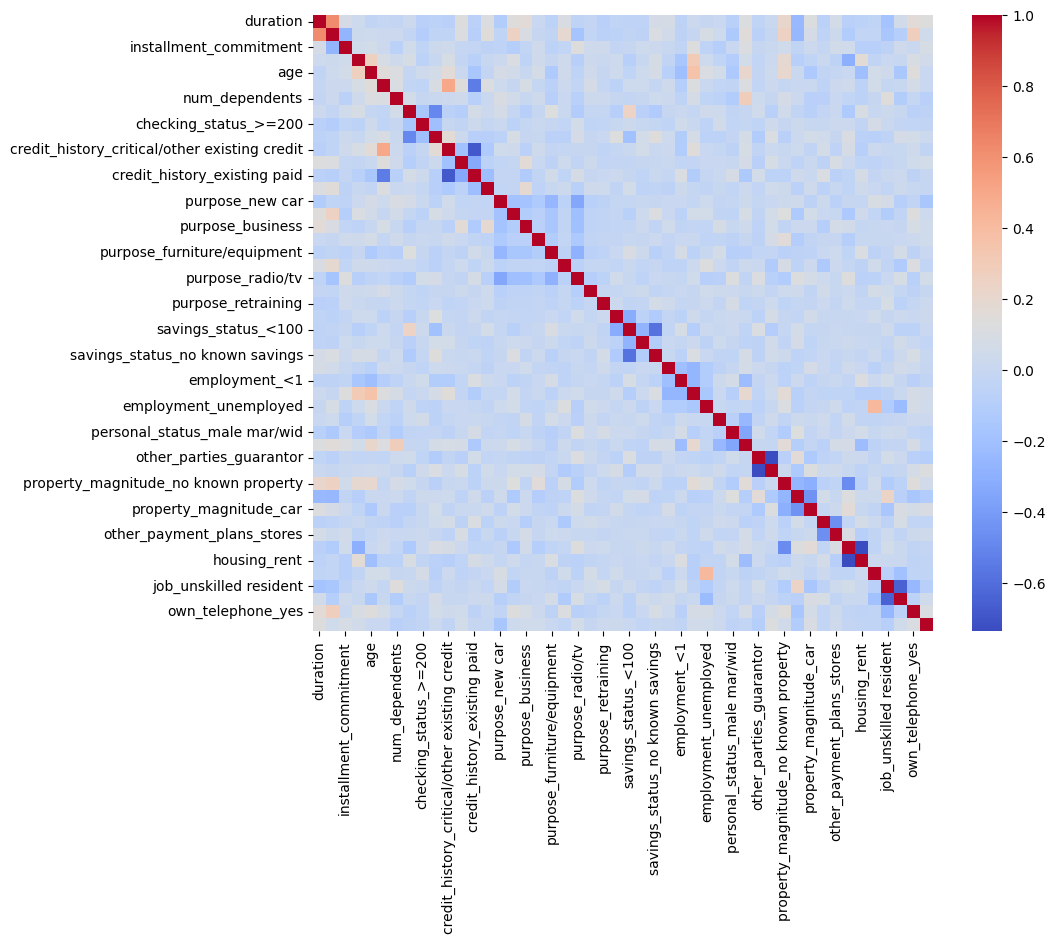

In [17]:
plt.figure(figsize=(10,8))
sns.heatmap(X.corr(), cmap="coolwarm")

> Check summary statistics

In [19]:
X.describe()

,duration,credit_amount,installment_commitment,residence_since,age,existing_credits,num_dependents
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,20.903000,3271.258000,2.973000,2.845000,35.546000,1.407000,1.155000
std,12.058814,2822.736876,1.118715,1.103718,11.375469,0.577654,0.362086
min,4.000000,250.000000,1.000000,1.000000,19.000000,1.000000,1.000000
25%,12.000000,1365.500000,2.000000,2.000000,27.000000,1.000000,1.000000
50%,18.000000,2319.500000,3.000000,3.000000,33.000000,1.000000,1.000000
75%,24.000000,3972.250000,4.000000,4.000000,42.000000,2.000000,1.000000
max,72.000000,18424.000000,4.000000,4.000000,75.000000,4.000000,2.000000


> Train-test split

In [67]:
X = X.astype(float)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)
print(f"X_train: {X_train.shape}")
print(f"X_test: {X_test.shape}")
print(f"y_train: {y_train.shape}")
print(f"y_test: {y_test.shape}")

X_train: (700, 48)
X_test: (300, 48)
y_train: (700,)
y_test: (300,)


In [68]:
X.dtypes

duration                                         float64
credit_amount                                    float64
installment_commitment                           float64
residence_since                                  float64
age                                              float64
existing_credits                                 float64
num_dependents                                   float64
checking_status_<0                               float64
checking_status_>=200                            float64
checking_status_no checking                      float64
credit_history_critical/other existing credit    float64
credit_history_delayed previously                float64
credit_history_existing paid                     float64
credit_history_no credits/all paid               float64
purpose_new car                                  float64
purpose_used car                                 float64
purpose_business                                 float64
purpose_education              

> Feature selection using Random Forest

In [69]:
rf = RandomForestClassifier(random_state=42).fit(X_train, y_train)

importances = pd.Series(rf.feature_importances_, index=X_train.columns)
top_features = importances.sort_values(ascending=False)

print(top_features)

credit_amount                                    0.116591
duration                                         0.095275
age                                              0.084030
checking_status_no checking                      0.051074
residence_since                                  0.038292
installment_commitment                           0.036420
checking_status_<0                               0.036180
credit_history_critical/other existing credit    0.028575
purpose_new car                                  0.024488
savings_status_<100                              0.023149
other_payment_plans_none                         0.020184
own_telephone_yes                                0.020180
existing_credits                                 0.019224
job_skilled                                      0.018000
property_magnitude_real estate                   0.017476
housing_own                                      0.017379
personal_status_male single                      0.017312
property_magni

> Get top 15 features and scale for KNN

### Train data → fit_transform
- You learn the scaling from the training data (mean & std)
- Then you apply it to the training data

### Test data → transform
- You don’t learn anything new from the test data
- You just apply the same scaling you learned from the training data

> The key idea: the model can’t “peek” at the test data. You only use what you learned from the train set.

In [70]:
X_train_selected = X_train[top_features.head(15).index]
X_test_selected = X_test[top_features.head(15).index]
X_train_selecte = X_train_selected.apply(pd.to_numeric)
X_test_selecte = X_test_selected.apply(pd.to_numeric)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_selected)
X_test_scaled = scaler.transform(X_test_selected)

X_train_sm = sm.add_constant(X_train_selected)
X_test_sm = sm.add_constant(X_test_selected)

print(f"X_train_selected: {X_train_selected.shape}")
print(f"X_test_selected: {X_test_selected.shape}")
print(f"X_train_scaled: {X_train_scaled.shape}")
print(f"X_test_scaled: {X_test_scaled.shape}")
print(f"X_train_sm: {X_train_sm.shape}")
print(f"X_test_sm: {X_test_sm.shape}")

X_train_selected: (700, 15)
X_test_selected: (300, 15)
X_train_scaled: (700, 15)
X_test_scaled: (300, 15)
X_train_sm: (700, 16)
X_test_sm: (300, 16)


> Train models

In [84]:
lpm_model = sm.OLS(y_train, X_train_sm).fit()

logit_model = sm.Logit(y_train, X_train_sm).fit()

knn_model = KNeighborsClassifier(n_neighbors=5).fit(X_train_scaled, y_train)
y_train_pred_knn = knn_model.predict(X_train_scaled)

dt_model = DecisionTreeClassifier(random_state=42).fit(X_train_selected, y_train)
y_train_pred_dt = dt_model.predict(X_train_selected)

Optimization terminated successfully.
         Current function value: 0.485552
         Iterations 6


In [87]:
print(lpm_model.summary())
print("\n\n\n")
print(logit_model.summary())
print("\n\n")
print(f"KNN Accuracy: {accuracy_score(y_train, y_train_pred_knn):.4f}")
print(f"DT Accuracy: {accuracy_score(y_train, y_train_pred_dt):.4f}")

                            OLS Regression Results                            
Dep. Variable:                  class   R-squared:                       0.220
Model:                            OLS   Adj. R-squared:                  0.203
Method:                 Least Squares   F-statistic:                     12.84
Date:                Wed, 04 Mar 2026   Prob (F-statistic):           1.38e-28
Time:                        19:46:07   Log-Likelihood:                -360.22
No. Observations:                 700   AIC:                             752.4
Df Residuals:                     684   BIC:                             825.3
Df Model:                          15                                         
Covariance Type:            nonrobust                                         
                                                    coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------------

> Model predict (test set)

In [90]:
y_pred_lpm = (lpm_model.predict(X_test_sm) >= 0.5).astype(int)

y_pred_logit = (logit_model.predict(X_test_sm) >= 0.5).astype(int)

y_pred_knn = knn_model.predict(X_test_scaled)

y_pred_dt = dt_model.predict(X_test_selected)

> Model evaluation

In [109]:
models = {"LPM": y_pred_lpm,
          "LOGIT": y_pred_logit,
          "KNN": y_pred_knn,
          "DT": y_pred_dt}

results = []

for name, y_pred in models.items():
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
    
    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1": f1_score(y_test, y_pred),
        "TP": tp,
        "TN": tn,
        "FP": fp,
        "FN": fn,
        "Type I Error Rate": round(fp / (fp + tn), 4),
        "Type II Error Rate": round(fn / (fn + tp), 4)
    })

results_df = pd.DataFrame(results).round(4)
results_df

,Model,Accuracy,Precision,Recall,F1,TP,TN,FP,FN,Type I Error Rate,Type II Error Rate
0,LPM,0.7433,0.7737,0.8952,0.8300,188,35,55,22,0.6111,0.1048
1,LOGIT,0.7467,0.7839,0.8810,0.8296,185,39,51,25,0.5667,0.1190
2,KNN,0.7433,0.7737,0.8952,0.8300,188,35,55,22,0.6111,0.1048
3,DT,0.6733,0.7593,0.7810,0.7700,164,38,52,46,0.5778,0.2190


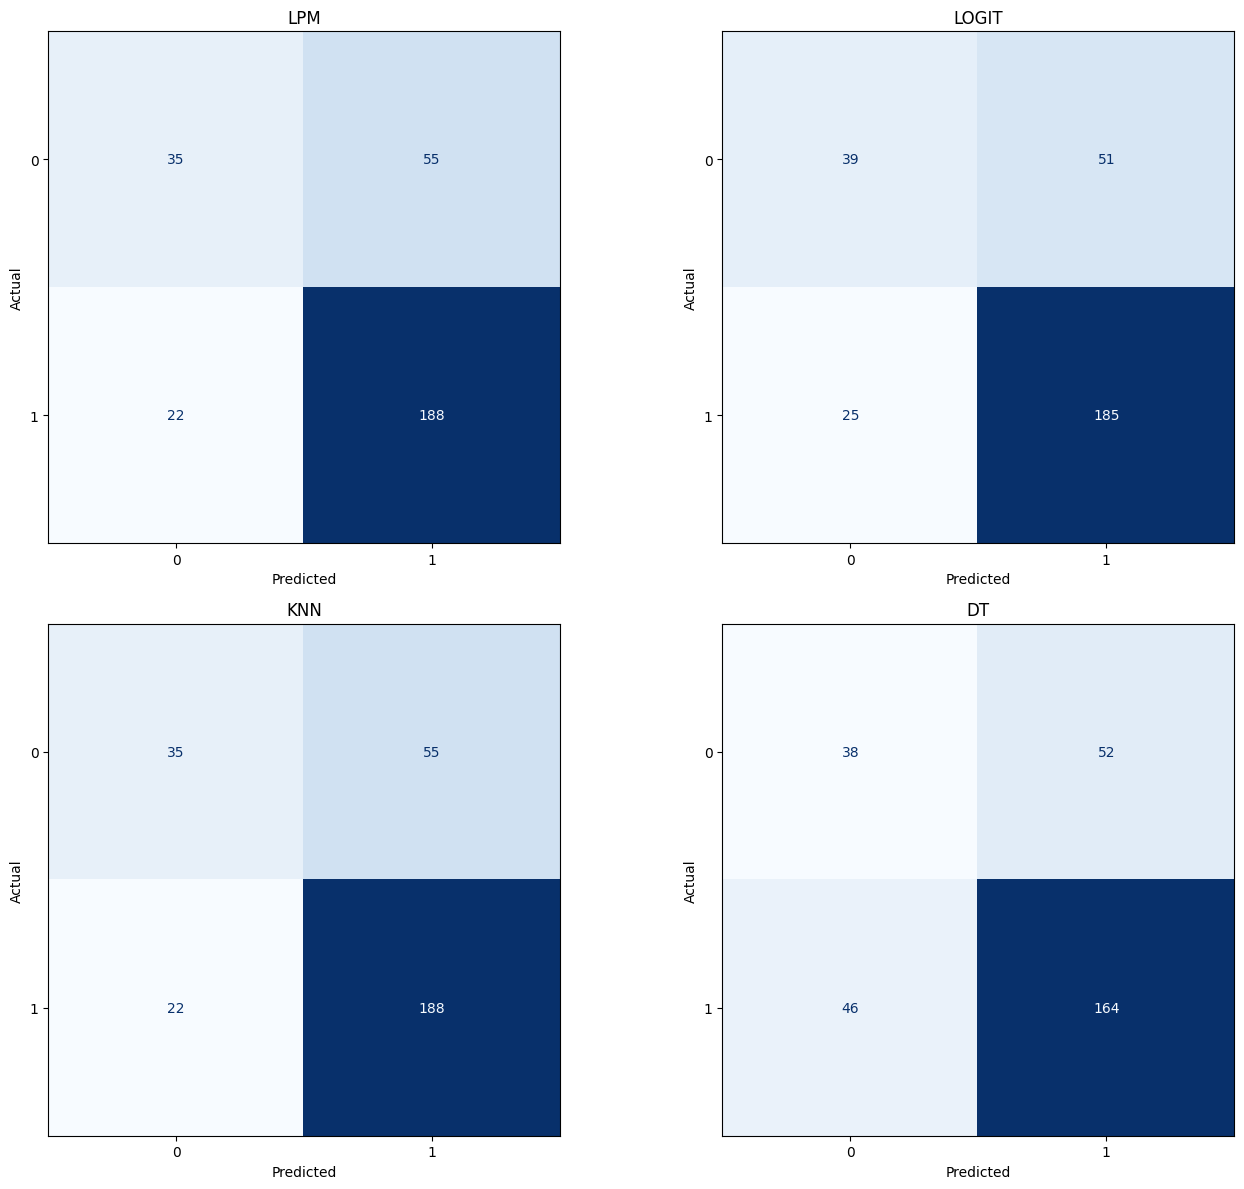

In [110]:
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
axes = axes.flatten()

for ax, (name, y_pred) in zip(axes, models.items()):
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=[0,1])
    disp.plot(ax=ax, cmap="Blues", colorbar=False, values_format='d')
    ax.set_title(name)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

plt.tight_layout()
plt.show()

# Model Comparison & Ranking – German Credit Dataset

Based on the evaluation metrics (Accuracy, Precision, Recall, F1, Type I Error Rate, Type II Error Rate), the four models are ranked as follows:

| Rank | Model          | Reason |
|------|----------------|--------|
| 1    | **Logit**      | Highest accuracy (~0.747), high F1 (~0.830), and lowest Type I error rate (fewer false positives). Best overall balance. |
| 2    | **LPM**        | Very similar to KNN in F1 and recall (~0.830, 0.895), but slightly higher Type I error than Logit. |
| 3    | **KNN**        | Similar metrics to LPM, slightly more sensitive to `k` value and scaling; matches LPM in this run. |
| 4    | **Decision Tree** | Lower accuracy (~0.673) and F1 (~0.770), higher Type II error (misses more positives). Needs hyperparameter tuning to improve performance. |

---

**Key Observations:**

- **Logit** is the best overall model for this dataset.  
- **LPM** and **KNN** are close seconds, performing similarly in terms of recall and F1.  
- **Decision Tree** underperforms with default parameters and would require tuning to match the linear models.  

**Notes on Errors:**

- **Type I Error (False Positive Rate)**: proportion of actual negatives incorrectly predicted as positives.  
- **Type II Error (False Negative Rate)**: proportion of actual positives incorrectly predicted as negatives.  

### Extra
> Is there a difference in LPM and KNN for this dataset?

In [113]:
# Find samples where predictions differ
diff_idx = ( (y_pred_lpm != y_pred_knn) )
X_test_selected[diff_idx]
y_test[diff_idx]

157    1
480    1
212    0
866    1
152    1
282    1
862    0
184    0
50     1
983    0
192    0
736    0
966    0
112    1
440    1
993    1
563    0
746    1
785    1
995    1
471    0
220    1
36     1
914    0
31     1
474    0
892    1
194    0
59     0
235    0
615    1
261    1
850    0
518    1
125    1
687    1
777    1
141    1
653    0
876    1
812    0
554    1
651    0
922    0
378    0
556    0
395    1
630    1
418    1
208    1
627    0
964    1
Name: class, dtype: int64

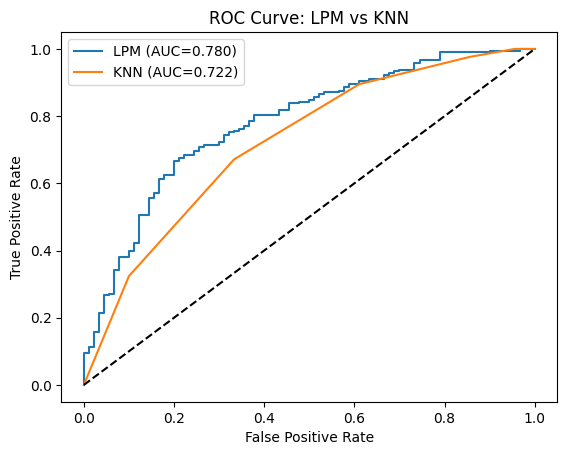

In [114]:
from sklearn.metrics import roc_curve, roc_auc_score

fpr_lpm, tpr_lpm, _ = roc_curve(y_test, y_prob_lpm)
fpr_knn, tpr_knn, _ = roc_curve(y_test, y_prob_knn)

plt.plot(fpr_lpm, tpr_lpm, label=f"LPM (AUC={roc_auc_score(y_test, y_prob_lpm):.3f})")
plt.plot(fpr_knn, tpr_knn, label=f"KNN (AUC={roc_auc_score(y_test, y_prob_knn):.3f})")
plt.plot([0,1], [0,1], "k--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve: LPM vs KNN")
plt.legend()
plt.show()

### Conclusions
- They have some difference in predictions. Therefore, they are not just copying nor was there a human error. Its just how the dataset behaves
- LPM performs better based on ROC-AUC graph